# 09 - Batch evaluation on five Set-A records

Goal: run the same fetal ECG pipeline on five PhysioNet Set-A records and summarize the FQRS detection performance.

## Why this step is needed

The previous notebooks build and explain the complete pipeline on `a14`. For the project, it is useful to show that the implementation can also be tested on multiple recordings. Here we keep the test small and clear: five records, no record-specific tuning.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pipeline

# Reload the local pipeline module so Jupyter picks up code changes.
importlib.reload(pipeline)

from pipeline import PipelineParameters, run_pipeline_for_record
from plotting import plot_batch_evaluation_summary


## Records selected for the test

We use five Set-A records:

`a10`, `a12`, `a13`, `a14`, `a15`

`a14` is the record used for detailed development. The other four records check whether the same code also runs on different signals. `a11` was not used in this small final batch because the PCA step did not converge on that record with the fixed parameters.

In [9]:
records_to_test = ['a10', 'a12', 'a13', 'a14', 'a15']
params = PipelineParameters()
records_to_test


['a10', 'a12', 'a13', 'a14', 'a15']

## Run the reusable pipeline

For each record, the code runs the same sequence:

`S1 -> S2 -> S3 -> S4 -> MQRS -> S5 -> FQRS -> performance`

The parameters are kept fixed for all five records.

In [10]:
rows = []
failed_rows = []

for record_name in records_to_test:
    print(f'Running pipeline for {record_name}...')
    try:
        result = run_pipeline_for_record(
            record_name,
            parameters=params,
            compute_average_fecg=False,
        )
        row = result.to_performance_row()
        row['status'] = 'ok'
        rows.append(row)
        print(
            f"  OK: detected={row['detected_fqrs']}, "
            f"reference={row['reference_fqrs']}, "
            f"F1={row['f1_score']:.3f}"
        )
    except Exception as exc:
        failed_rows.append({
            'record': record_name,
            'status': 'failed',
            'error': str(exc),
        })
        print(f'  FAILED: {exc}')

performance_table = pd.DataFrame(rows)
failed_table = pd.DataFrame(failed_rows, columns=['record', 'status', 'error'])
performance_table


Running pipeline for a10...
  OK: detected=47, reference=175, F1=0.261
Running pipeline for a12...
  OK: detected=134, reference=138, F1=0.912
Running pipeline for a13...
  OK: detected=125, reference=126, F1=0.932
Running pipeline for a14...
  OK: detected=124, reference=123, F1=0.899
Running pipeline for a15...
  OK: detected=102, reference=134, F1=0.407


,record,duration_s,channels,original_fs_hz,pipeline_fs_hz,reference_fqrs,detected_fqrs,true_positives,false_positives,false_negatives,...,positive_predictive_value,f1_score,mean_abs_error_ms,tolerance_ms,mqrs_detected,mecg_cancelled_mqrs,mean_rr_ms,median_rr_ms,estimated_fhr_bpm,status
0,a10,60.0,4,1000.0,2000.0,175,47,29,18,146,...,0.617021,0.261261,16.327586,50.0,110,99,1296.597826,753.50,46.274950,ok
1,a12,60.0,4,1000.0,2000.0,138,134,124,10,14,...,0.925373,0.911765,5.366935,50.0,87,76,447.296992,442.00,134.139064,ok
2,a13,60.0,4,1000.0,2000.0,126,125,117,8,9,...,0.936000,0.932271,9.581197,50.0,81,71,480.411290,478.75,124.892985,ok
3,a14,60.0,4,1000.0,2000.0,123,124,111,13,12,...,0.895161,0.898785,6.396396,50.0,102,91,485.353659,483.00,123.621197,ok
4,a15,60.0,4,1000.0,2000.0,134,102,48,54,86,...,0.470588,0.406780,7.166667,50.0,114,102,589.569307,541.00,101.769206,ok


## Summary statistics

This table gives the mean and standard deviation of the main metrics across the successful records.

In [11]:
metric_columns = [
    'reference_fqrs',
    'detected_fqrs',
    'sensitivity',
    'positive_predictive_value',
    'f1_score',
    'mean_abs_error_ms',
    'estimated_fhr_bpm',
]

summary_rows = []
if not performance_table.empty:
    for metric in metric_columns:
        values = pd.to_numeric(performance_table[metric], errors='coerce')
        summary_rows.append({
            'metric': metric,
            'mean': values.mean(),
            'std': values.std(ddof=1),
            'min': values.min(),
            'max': values.max(),
        })

summary_table = pd.DataFrame(summary_rows)
summary_table


,metric,mean,std,min,max
0,reference_fqrs,139.200000,20.897368,123.000000,175.000000
1,detected_fqrs,106.400000,35.232088,47.000000,134.000000
2,sensitivity,0.650697,0.361517,0.165714,0.928571
3,positive_predictive_value,0.768829,0.212371,0.470588,0.936000
4,f1_score,0.682172,0.322176,0.261261,0.932271
5,mean_abs_error_ms,8.967756,4.397873,5.366935,16.327586
6,estimated_fhr_bpm,106.139480,35.511063,46.274950,134.139064


## Save batch results

The detailed table and the summary table are saved in `results/notebook09/`.

In [12]:
results_dir = PROJECT_ROOT / 'results' / 'notebook09'
results_dir.mkdir(parents=True, exist_ok=True)

performance_path = results_dir / 'set_a_5_records_performance.csv'
summary_path = results_dir / 'set_a_5_records_summary.csv'
failed_path = results_dir / 'set_a_5_records_failures.csv'

performance_table.to_csv(performance_path, index=False)
summary_table.to_csv(summary_path, index=False)
failed_table.to_csv(failed_path, index=False)

print(performance_path)
print(summary_path)
print(failed_path)


/app/results/notebook09/set_a_5_records_performance.csv
/app/results/notebook09/set_a_5_records_summary.csv
/app/results/notebook09/set_a_5_records_failures.csv


## Compact presentation table

This version keeps only the columns that are easiest to show in a final slide.

In [13]:
presentation_columns = [
    'record',
    'reference_fqrs',
    'detected_fqrs',
    'sensitivity',
    'positive_predictive_value',
    'f1_score',
    'mean_abs_error_ms',
    'estimated_fhr_bpm',
]

presentation_table = performance_table[presentation_columns].copy()
for column in ['sensitivity', 'positive_predictive_value', 'f1_score']:
    presentation_table[column] = presentation_table[column] * 100
presentation_table = presentation_table.round({
    'sensitivity': 1,
    'positive_predictive_value': 1,
    'f1_score': 1,
    'mean_abs_error_ms': 2,
    'estimated_fhr_bpm': 2,
})
presentation_table


,record,reference_fqrs,detected_fqrs,sensitivity,positive_predictive_value,f1_score,mean_abs_error_ms,estimated_fhr_bpm
0,a10,175,47,16.6,61.7,26.1,16.33,46.27
1,a12,138,134,89.9,92.5,91.2,5.37,134.14
2,a13,126,125,92.9,93.6,93.2,9.58,124.89
3,a14,123,124,90.2,89.5,89.9,6.40,123.62
4,a15,134,102,35.8,47.1,40.7,7.17,101.77


## Batch performance figure

This figure gives a visual comparison of the five records. The top panel compares sensitivity, PPV, and F1-score. The bottom panel compares the number of reference fetal beats with the number detected by the algorithm.

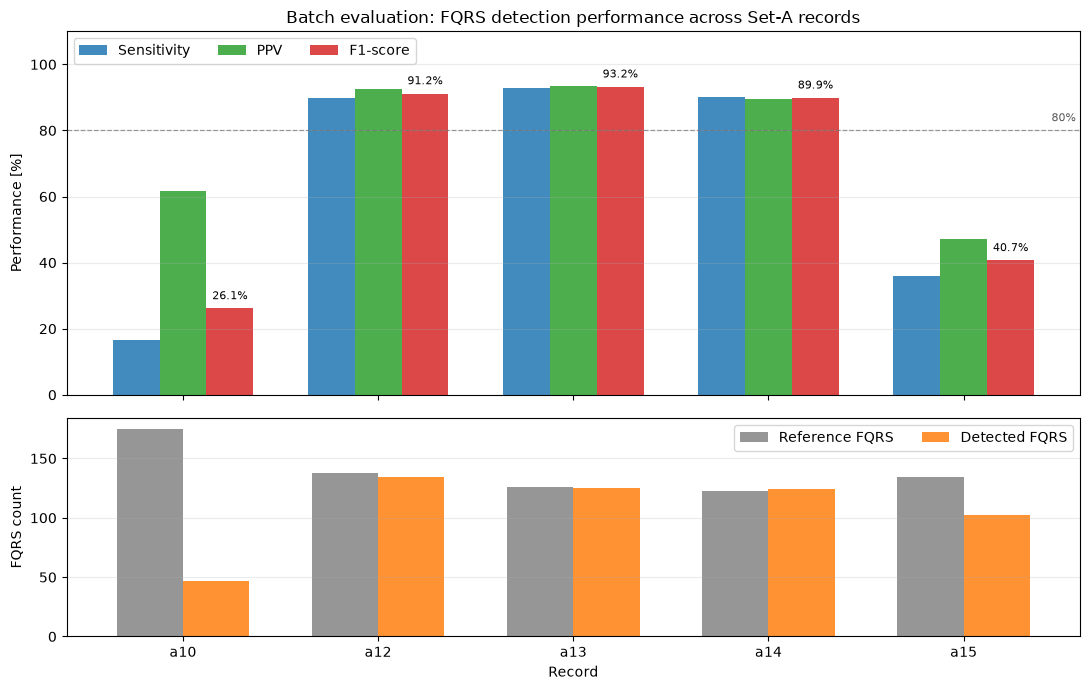

In [14]:
fig, axes = plot_batch_evaluation_summary(
    performance_table,
    save_path=PROJECT_ROOT / 'figures' / 'notebook09' / 'set_a_5_records_batch_performance.png',
)
plt.show()


## Output of this step

This notebook does not tune the algorithm for each record. It simply applies the same pipeline to five recordings and saves the performance tables. The tables and the batch performance figure are useful for the final results slide.